# Decision Trees

<img src="./img/5_decision_tree.png" width="700px"><br><br>

### Definition:

_"A decision tree is a non-parametric supervised learning algorithm, ... .  
It has a hierarchical, tree structure, which consists of a root node, branches, internal nodes and leaf nodes."_

<span style="font-size: 70%">Source: <a href="https://www.ibm.com/topics/decision-trees">IBM</a></span><br><br>

There are several algorithms that implement `Decision Trees`:

> &nbsp;
> - __ID3__ (`Iterative Dichotomiser 3`): This algorithm leverages __entropy__ and __information gain__ as metrics to evaluate candidate splits.<br><br>
> - __C4.5__: Advanced ID3 implementation that uses __information gain__ or __gain ratios__ to evaluate split points.<br><br>
> - __C5.0__: Latest ID3 implementation released under a proprietary license<br><br>
> - __CART__ (`Classification and Regression Trees`): This algorithm typically utilizes __Gini impurity__ to identify the ideal attribute to split on.<br>Gini impurity measures how often a randomly chosen attribute is misclassified (smaller is better).
> <br><br>

<br><br>

### Some theory

__Def: Entropy__

$ Entropy \left( S \right) = - \sum_{c \in C} p (c) \log_2 p (c) $ 

with 

$ S $ ... data set  
$ c $ ... classes in the set $ S $  
$ p(c) $ ... proportion of data points of class $ c $ to total data points in $ S $

$ Entropy \left( s \right) ... \> [0, 1] $

<br><br>

__Def: Information Gain__

$ Information Gain \left( S, \alpha \right) = Entropy \left( S \right) -\sum_{v \in C} \dfrac{ \left| S_v \right| }{ S } Entropy \left( S_v \right) $

with

$ \alpha $ ... specific attribute or class  
$ \dfrac{ \left| S_v \right| }{ S } $ ... portion of values in $ S_v $ to the total number of values in $ S $  

<br><br>

__DEF: Gini Impurity index__

$ Gini = 1 - \sum_i \left( p_i \right)^2 $

with

$ p_i $ ... probability of class $ i $

<span style="font-size: 70%">Source: <a href="https://en.wikipedia.org/wiki/Decision_tree_learning#Gini_impurity">Wikipedia</a></span>

##### Comparison of selection characteristics

<img src="./img/5_entropy_vs_gini.png" width="700px"><br><br>

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Read about <a href="https://en.wikipedia.org/wiki/Decision_tree_learning">Decision Tree learning</a> in Wikipedia,</li>
<li><a href="https://scikit-learn.org/stable/modules/tree.html#decision-trees">Decision Trees</a> in Scikit learn</li>
</ul>
</td>
</tr>
</table>

__Note:__

`Scikit learn` offers the output of decision trees in graphical form. To benefit from this, you need to install `graphviz` on you computer and `pydot` in your Python environment.

1. Go to [Graphviz](https://graphviz.org/download) to install `graphviz` library.

1. <pre>pip install -U pyplot</pre>

In [1]:
# to install pyplot, uncomment the following line

# !pip install -U pyplot

### IRIS Classification using Decision Trees

In [2]:
# obligatory imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import confusion_matrix, accuracy_score

As we know the data already, we need not repeat data analysis here.

In [3]:
# prepare the data
iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [4]:
# model generation

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

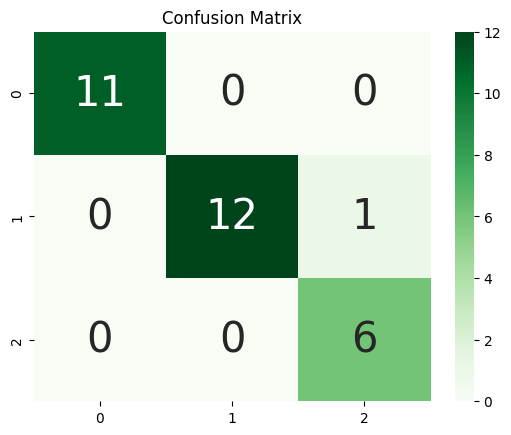

Accuracy:
 Train: 100.00 %
 Test:  96.67 %


In [5]:
# test model quality

y_pred=dt.predict(X_test)

# generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# visualize the confusion matrix
ax = plt.axes()
sns.heatmap(cm, annot=True, annot_kws={"size": 30}, cmap="Greens", ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

print('Accuracy:')
print(f' Train: {accuracy_score(y_train, dt.predict(X_train))*100:.2f} %')
print(f' Test:  {accuracy_score(y_test, y_pred)*100:.2f} %')


##### Decision boundaries

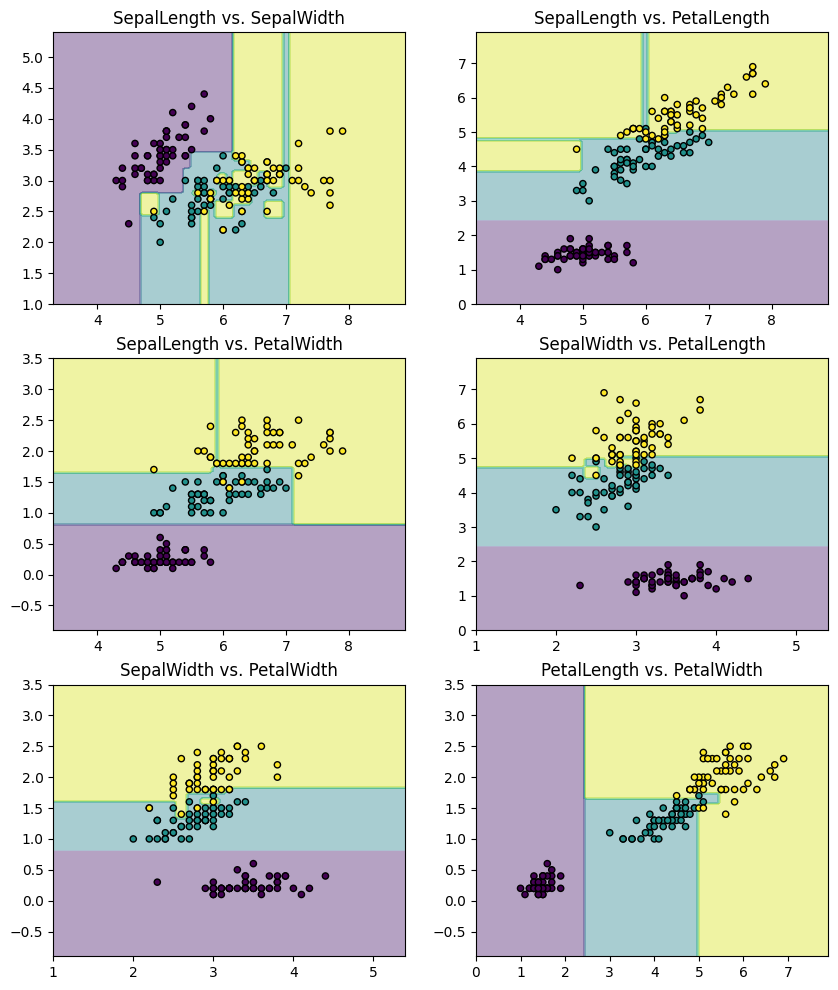

In [6]:
# only needed for display of decission boundaries
from itertools import product
from sklearn.inspection import DecisionBoundaryDisplay

# create a dataframe for statistic evaluation
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
df = pd.DataFrame(iris.data, columns=feature_columns)
df['Species'] = pd.Series(iris.target_names[iris.target])

# all combinations to compare
X_cols_combo = [["SepalLengthCm", "SepalWidthCm"], ["SepalLengthCm", "PetalLengthCm"],
                ["SepalLengthCm", "PetalWidthCm"], ["SepalWidthCm", "PetalLengthCm"],
                ["SepalWidthCm", "PetalWidthCm"], ["PetalLengthCm", "PetalWidthCm"]]

# comparing datasets
X1 = df[X_cols_combo[0]].to_numpy()
X2 = df[X_cols_combo[1]].to_numpy()
X3 = df[X_cols_combo[2]].to_numpy()
X4 = df[X_cols_combo[3]].to_numpy()
X5 = df[X_cols_combo[4]].to_numpy()
X6 = df[X_cols_combo[5]].to_numpy()
y = iris.target

# generating a forrest of classifiers
clf_1 = DecisionTreeClassifier()
clf_2 = DecisionTreeClassifier()
clf_3 = DecisionTreeClassifier()
clf_4 = DecisionTreeClassifier()
clf_5 = DecisionTreeClassifier()
clf_6 = DecisionTreeClassifier()

# make things iterable
clf_all = [clf_1, clf_2, clf_3, clf_4, clf_5, clf_6]
X_sets = [X1, X2, X3, X4, X5, X6]

# helper to generate the image position
img_pos = [pos_t for pos_t in product([0, 1, 2], [0, 1])]

f, ax = plt.subplots(3, 2, figsize=(10, 12))

for i, classifier in enumerate(clf_all):
    classifier.fit(X_sets[i], y)
    DecisionBoundaryDisplay.from_estimator(
        classifier, X_sets[i], alpha=0.4, ax=ax[img_pos[i][0], img_pos[i][1]], response_method="predict")
    ax[img_pos[i][0], img_pos[i][1]].scatter(X_sets[i][:, 0], X_sets[i][:, 1], c=y, s=20, edgecolor="k")
    ax[img_pos[i][0], img_pos[i][1]].set_title(f"{X_cols_combo[i][0][:-2]} vs. {X_cols_combo[i][1][:-2]}")


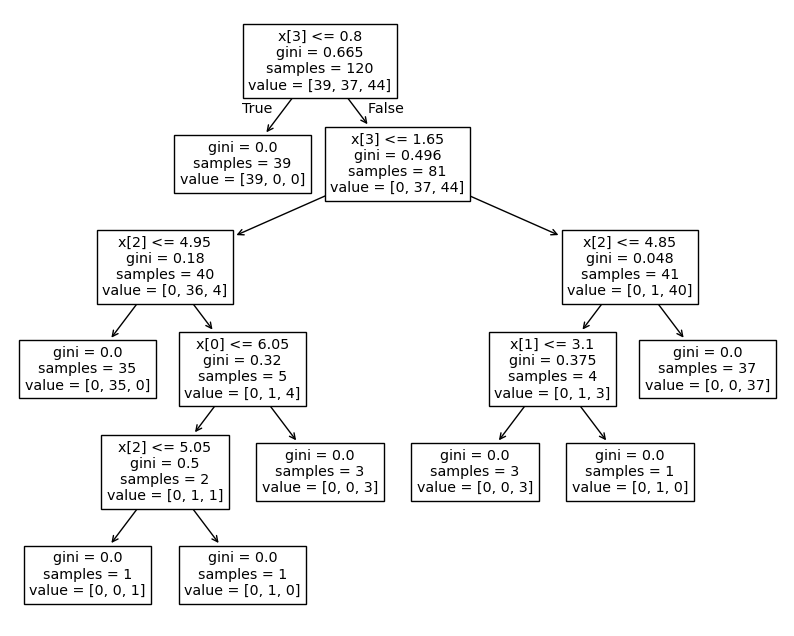

In [7]:
# plot decision tree

plt.figure(figsize=(10,8))
plot_tree(decision_tree=dt)
plt.show()

# Ensemble methods

Ensemble methods combine several base estimators to provide better generalization and robustness over single purpose estimators.

One such ensemble method (not exclusively) is ...

### Random Forest Trees

<img src="./img/5_Random_forest_diagram_complete.png">

<table>
<tr>
<td style="border-style: none"><img src="./img/0_reference.png" height="100px"></td>
<td style="border-style: none">&nbsp;&nbsp;</td>
<td style="border-style: none; vertical-align: middle"><u>Further reading:</u>
<ul>
<li>Read about <a href="https://scikit-learn.org/stable/modules/ensemble.html#forest">Ensemble methods</a> in Scikit learn</li>
<li><a href="https://en.wikipedia.org/wiki/Random_forest">Random forest</a> in Wikipedia,</li>
</ul>
</td>
</tr>
</table>

Let's see if `Random forest` classifiers improve our prediction.

In [8]:
# imports

from sklearn.ensemble import RandomForestClassifier

In [9]:
# model generation

rf = RandomForestClassifier(oob_score=True)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

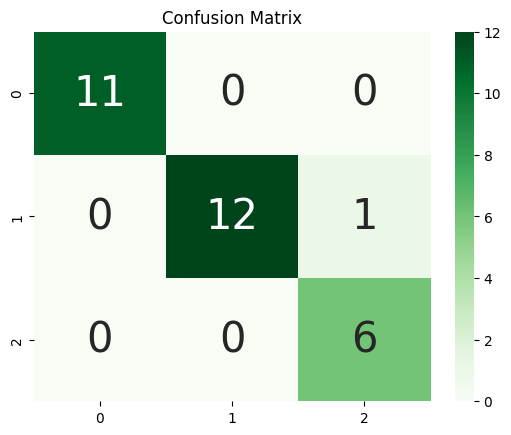

Accuracy:
 Train: 100.00 %
 Test:  96.67 %


In [10]:
# test model quality

y_pred = rf.predict(X_test)

# generate a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# visualize the confusion matrix
ax = plt.axes()
sns.heatmap(cm, annot=True, annot_kws={"size": 30}, cmap="Greens", ax=ax)
ax.set_title('Confusion Matrix')
plt.show()

print('Accuracy:')
print(f' Train: {accuracy_score(y_train, rf.predict(X_train))*100:.2f} %')
print(f' Test:  {accuracy_score(y_test, y_pred)*100:.2f} %')


In [11]:
print(f"RandomForestClassifier uses {len(rf.estimators_)} Decision Tree Classifiers")

RandomForestClassifier uses 100 Decision Tree Classifiers


Random forest provides feature importance

In [12]:
rf.feature_importances_

array([0.10825525, 0.02826474, 0.45669363, 0.40678638])

In this data set, features 3 (Petal length) and 4 (Petal width) contribute the most to the decision process.

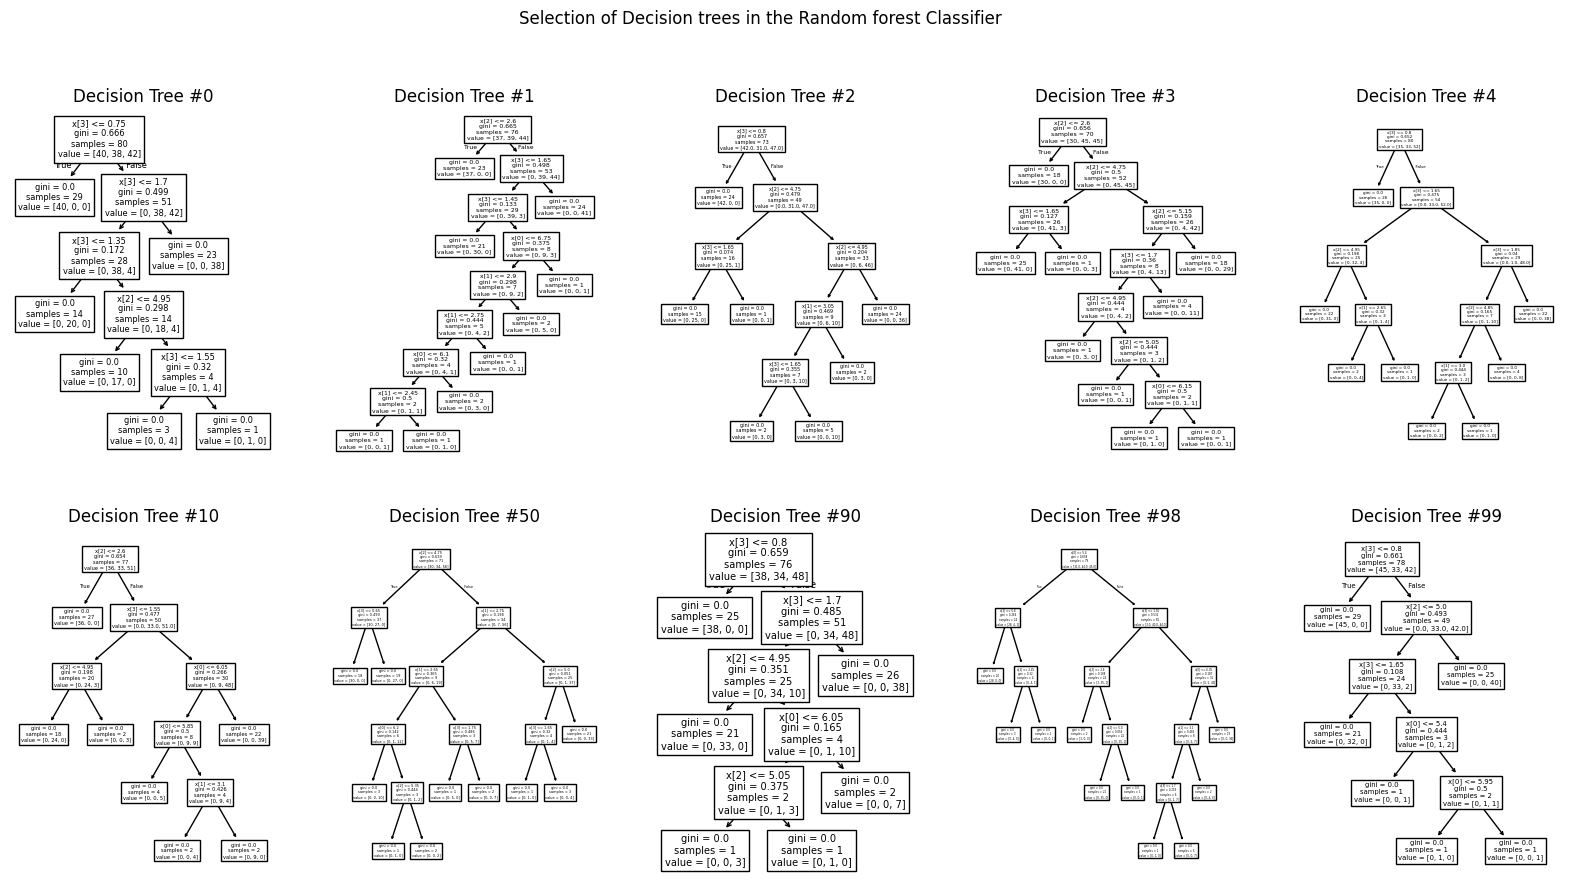

In [13]:
img_pos = [pos for pos in product([0, 1], [0, 1, 2, 3, 4])]
estimators = [0, 1, 2, 3, 4, 10, 50, 90, 98, 99]

f, ax = plt.subplots(2, 5, figsize=(20, 10))

f.suptitle("Selection of Decision trees in the Random forest Classifier")
for i, estimator in enumerate(estimators):
    plot_tree(rf.estimators_[estimator], ax=ax[img_pos[i][0]][img_pos[i][1]])
    ax[img_pos[i][0]][img_pos[i][1]].set_title(f"Decision Tree #{estimator}")
plt.show()

<img src="./img/0_critical_evaluation.png" width="150px">

### Critical evaluation

In this example, `Decision Trees` and `Random Forests` provide similar accuracy.

In general, ensemble methods provide better generalization over single method models.